
# MSIT 3103 · Assignment 3 Hotstart Notebook  
**Prompt Engineering Lab with Local Models (Ollama + LLaMA 3.2 1B)**

> Use this notebook to run structured prompt‑engineering experiments on a **local** small model (e.g., `llama3.2:1b` via Ollama).  
> You will implement Steps 1–4 (Basic → Structured → Few‑shot → CoT), collect outputs, and analyze results.



## 0) Local Environment Check

This notebook assumes you have **[Ollama](https://ollama.com/)** installed locally and the `llama3.2:1b` model available.

- Install Ollama: follow your OS‑specific steps from the website.  
- Pull the model (in a terminal):  
```bash
ollama pull llama3.2:1b
```
- Verify command works (from terminal): `ollama run llama3.2:1b "hello"`

> If you're executing this notebook on a machine without Ollama, use these cells as **documentation** and run the actual commands on your local machine. You can paste results back here for analysis.


In [1]:
import subprocess

OLLAMA = r"C:\Users\kudza\AppData\Local\Programs\Ollama\ollama.exe"

def ollama_run(prompt, model="llama3.2:1b"):
    result = subprocess.run(
        [OLLAMA, "run", model, prompt],
        capture_output=True,
        text=True,
        encoding="utf-8",
        errors="replace"
    )
    return (result.stdout or "").strip()


In [2]:
response = ollama_run("Say OK only.")
print(response)


OK


In [3]:

import json, os, subprocess, time, uuid, textwrap
from dataclasses import dataclass, asdict
from typing import List, Dict

RESULTS_DIR = "a3_outputs"
os.makedirs(RESULTS_DIR, exist_ok=True)
OLLAMA_PATH = r"C:\Users\kudza\AppData\Local\Programs\Ollama\ollama.exe"

def ollama_run(model: str, prompt: str, options: Dict=None, timeout: int = 120) -> str:
    """Run a prompt through a local Ollama model via subprocess and return the text."""
    
    cmd = [OLLAMA_PATH, "run", model]

    proc = subprocess.run(
        cmd,
        input=prompt.encode("utf-8"),
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        timeout=timeout
    )

    if proc.returncode != 0:
        raise RuntimeError(
            f"Ollama error: {proc.stderr.decode('utf-8', errors='ignore')}"
        )

    return proc.stdout.decode("utf-8", errors="ignore").strip()

@dataclass
class Trial:
    step: str                 # basic / structured / fewshot / cot
    task_id: str              # arbitrary id of the task/question
    prompt: str
    response: str
    meta: Dict

def save_trials(trials: List[Trial], path: str):
    with open(path, "w", encoding="utf-8") as f:
        json.dump([asdict(t) for t in trials], f, ensure_ascii=False, indent=2)
    print(f"Saved {len(trials)} trials to {path}")


In [4]:
print(ollama_run("llama3.2:1b", "Say OK only."))


OK.



## 1) Context Document & Tasks

Create/Load a short **context document** (few paragraphs) and a small set of **tasks** to query the model with.  
You may replace the placeholder context and tasks below with your own domain (e.g., finance, health, policy, product requirements).

> Keep **5–10 tasks** so runs complete quickly.


In [5]:

CONTEXT = """
Health refers to the overall physical and mental well-being of a person. Maintaining good health requires a balanced diet, regular physical activity, adequate sleep, and proper hygiene.

Eating fruits, vegetables, whole grains, and lean proteins helps the body function properly. Drinking enough water and limiting sugary foods and processed snacks are also important for maintaining a healthy weight.

Regular exercise strengthens the heart, muscles, and bones. It also reduces stress and improves mood. Adults are generally encouraged to engage in at least 30 minutes of moderate physical activity most days of the week.

Preventive healthcare includes routine medical check-ups, vaccinations, and early detection of diseases. Visiting a healthcare provider regularly can help prevent serious health problems in the future.
""".strip()

TASKS = [
    {"id": "t1", "question": "Define health according to the context."},
    {"id": "t2", "question": "List three ways to maintain good health."},
    {"id": "t3", "question": "Why is regular exercise important?"},
    {"id": "t4", "question": "What foods are recommended for a healthy diet?"},
    {"id": "t5", "question": "What is preventive healthcare?"},
    {"id": "t6", "question": "Does the context mention mental illness treatment programs? If not, state 'Not provided in context.'"}
]

print(CONTEXT)
print("\nTasks:")
for t in TASKS:
    print("-", t["id"] + ":", t["question"])


Health refers to the overall physical and mental well-being of a person. Maintaining good health requires a balanced diet, regular physical activity, adequate sleep, and proper hygiene.

Eating fruits, vegetables, whole grains, and lean proteins helps the body function properly. Drinking enough water and limiting sugary foods and processed snacks are also important for maintaining a healthy weight.

Regular exercise strengthens the heart, muscles, and bones. It also reduces stress and improves mood. Adults are generally encouraged to engage in at least 30 minutes of moderate physical activity most days of the week.

Preventive healthcare includes routine medical check-ups, vaccinations, and early detection of diseases. Visiting a healthcare provider regularly can help prevent serious health problems in the future.

Tasks:
- t1: Define health according to the context.
- t2: List three ways to maintain good health.
- t3: Why is regular exercise important?
- t4: What foods are recommended


## 2) Step 1 — Basic Prompting

- Ask direct, simple questions grounded in the context document.
- Log correctness, completeness, and clarity for later comparison.


In [6]:

MODEL = "llama3.2:1b"

basic_trials = []
for task in TASKS:
    prompt = f"""
You are a helpful assistant.

Context:
{CONTEXT}

Question:
{task['question']}
""".strip()
    try:
        resp = ollama_run(MODEL, prompt)
    except Exception as e:
        resp = f"[ERROR running model locally] {e}"
    basic_trials.append(Trial(step="basic", task_id=task["id"], prompt=prompt, response=resp, meta={}))

save_trials(basic_trials, os.path.join(RESULTS_DIR, "step1_basic.json"))


Saved 6 trials to a3_outputs\step1_basic.json



## 3) Step 2 — Structured Output Prompts

- Instruct the model to output **strict JSON** or bullet lists/tables.
- Compare accuracy & reliability with Step 1.


In [7]:

structured_trials = []
for task in TASKS:
    prompt = f"""
You are a helpful assistant. Return the answer in **strict JSON** with keys:
- "answer": string
- "supporting_facts": list of short strings derived from the context
- "confidence": number in [0,1]

Context:
{CONTEXT}

Question:
{task['question']}

If something is unknowable from the context, set "confidence": 0 and use an empty "supporting_facts".
""".strip()
    try:
        resp = ollama_run(MODEL, prompt)
    except Exception as e:
        resp = f"[ERROR running model locally] {e}"
    structured_trials.append(Trial(step="structured", task_id=task["id"], prompt=prompt, response=resp, meta={"format":"json"}))

save_trials(structured_trials, os.path.join(RESULTS_DIR, "step2_structured.json"))


Saved 6 trials to a3_outputs\step2_structured.json


In [8]:
for t in structured_trials:
    print("\n-------------------------")
    print("Task ID:", t.task_id)
    print("Response:\n", t.response)



-------------------------
Task ID: t1
Response:
 ```
{
  "answer": "Health refers to the overall physical and mental well-being of a person.",
  "supporting_facts": [
    "Maintaining good health requires a balanced diet, regular physical activity, adequate sleep, and proper hygiene.",
    "Eating fruits, vegetables, whole grains, and lean proteins helps the body function properly.",
    "Drinking enough water and limiting sugary foods and processed snacks are also important for maintaining a healthy weight."
  ],
  "confidence": 0.9
}
```

-------------------------
Task ID: t2
Response:
 ```json
{
    "answer": "Maintaining Good Health",
    "supporting_facts": [],
    "confidence": 1.0
}
```

I've listed three ways to maintain good health based on the context, without providing any information about things that are unknowable or unattainable.

-------------------------
Task ID: t3
Response:
 ```json
{
    "answer": "Regular exercise strengthens the heart, muscles, and bones.",
    "


## 4) Step 3 — Few‑shot Prompting

- Provide **1–3 short examples** to steer the style & content.
- Compare results with Steps 1–2.


In [9]:

FEW_SHOT_EXAMPLES = [
    {
        "q": "Define health based on the context.",
        "a": "Health refers to a person's overall physical and mental well-being."
    },
    {
        "q": "List two ways to maintain good health.",
        "a": "- Eat a balanced diet\n- Exercise regularly"
    }
]


def render_fewshot_block(examples):
    parts = ["You are a helpful assistant. Here are some QA examples:"]
    for ex in examples:
        parts.append(f"Q: {ex['q']}\nA: {ex['a']}")
    return "\n\n".join(parts)

fewshot_prefix = render_fewshot_block(FEW_SHOT_EXAMPLES)

fewshot_trials = []
for task in TASKS:
    prompt = f"""
{fewshot_prefix}

Now answer the new question using the context below.

Context:
{CONTEXT}

Question:
{task['question']}
""".strip()
    try:
        resp = ollama_run(MODEL, prompt)
    except Exception as e:
        resp = f"[ERROR running model locally] {e}"
    fewshot_trials.append(Trial(step="fewshot", task_id=task["id"], prompt=prompt, response=resp, meta={"k": len(FEW_SHOT_EXAMPLES)}))

save_trials(fewshot_trials, os.path.join(RESULTS_DIR, "step3_fewshot.json"))


Saved 6 trials to a3_outputs\step3_fewshot.json


In [10]:
for t in fewshot_trials:
    print("\n-------------------------")
    print("Task:", t.task_id)
    print(t.response)



-------------------------
Task: t1
Based on the context provided, health refers to the overall physical and mental well-being of a person.

-------------------------
Task: t2
Based on the context, here are three ways to maintain good health:

1. Eat a balanced diet
2. Exercise regularly
3. Get adequate sleep and practice proper hygiene.

-------------------------
Task: t3
According to the context, regular exercise is important for maintaining overall physical and mental well-being. It helps strengthen the heart, muscles, and bones, reduces stress and improves mood, and also prevents serious health problems in the future.

-------------------------
Task: t4
Based on the context, here are some food recommendations for a healthy diet:

1. Fruits: Eat a variety of fruits to provide essential vitamins, minerals, and antioxidants.
2. Vegetables: Include leafy greens, broccoli, carrots, and other vegetables in your diet to get important nutrients like vitamins A, C, and K, as well as fiber a


## 5) Step 4 — Chain‑of‑Thought (CoT) Prompting

- Encourage explicit reasoning (e.g., _"Let's think step by step."_).  
- Compare reasoning quality, correctness, and verbosity with prior steps.

> **Note:** When writing your report, avoid pasting raw CoT traces if disallowed by an evaluation policy. Summarize the reasoning instead.


In [11]:

cot_trials = []
for task in TASKS:
    prompt = f"""
You are a helpful assistant. Let's think step by step and show reasoning before the final answer.
Use the context to avoid hallucinations. Provide a short final answer at the end under 'Final Answer: ...'.

Context:
{CONTEXT}

Question:
{task['question']}
""".strip()
    try:
        resp = ollama_run(MODEL, prompt)
    except Exception as e:
        resp = f"[ERROR running model locally] {e}"
    cot_trials.append(Trial(step="cot", task_id=task["id"], prompt=prompt, response=resp, meta={"cot": True}))

save_trials(cot_trials, os.path.join(RESULTS_DIR, "step4_cot.json"))


Saved 6 trials to a3_outputs\step4_cot.json


In [12]:
for t in cot_trials:
    print("\n-------------------------")
    print("Task:", t.task_id)
    print(t.response)


-------------------------
Task: t1
To define health according to the given context, let's analyze the key points:

1. Maintaining good physical and mental well-being.
2. Requires a balanced diet, regular physical activity, adequate sleep, and proper hygiene.
3. Involves consuming fruits, vegetables, whole grains, lean proteins, drinking water, limiting sugary foods, and processed snacks.

Based on these points, we can infer that health is characterized by:

* A balance of physical (disease prevention) and mental well-being (mental health)
* Adequate consumption of essential nutrients
* Regular physical activity to maintain overall fitness
* Proper hydration and a healthy sleep schedule

Considering the importance of preventive healthcare, regular check-ups, vaccinations, and early disease detection, we can conclude that:

Health refers to an individual's ability to maintain their physical and mental well-being, which is supported by a balanced lifestyle, regular medical care, and prev


## 6) Scoring Scaffold (Manual or Programmatic)

Rate each response on:
- **Correctness** (0–5), **Completeness** (0–5), **Clarity** (0–5).  
Optionally mark factual errors.

Fill the table below manually (or write a simple heuristic scorer).


In [13]:

import json, glob, pandas as pd

def load_trials(pattern):
    rows = []
    for path in sorted(glob.glob(pattern)):
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
        for item in data:
            rows.append({
                "file": os.path.basename(path),
                "step": item["step"],
                "task_id": item["task_id"],
                "prompt": item["prompt"],
                "response": item["response"],
            })
    return pd.DataFrame(rows)

df = load_trials(os.path.join(RESULTS_DIR, "step*.json"))
df.head()


,file,step,task_id,prompt,response
0,step1_basic.json,basic,t1,You are a helpful assistant.\n\nContext:\nHeal...,"Based on the provided context, I would define ..."
1,step1_basic.json,basic,t2,You are a helpful assistant.\n\nContext:\nHeal...,Here are three ways to maintain good health:\n...
2,step1_basic.json,basic,t3,You are a helpful assistant.\n\nContext:\nHeal...,Regular exercise is essential for maintaining ...
3,step1_basic.json,basic,t4,You are a helpful assistant.\n\nContext:\nHeal...,"To maintain good health, it's essential to foc..."
4,step1_basic.json,basic,t5,You are a helpful assistant.\n\nContext:\nHeal...,Preventive healthcare refers to the measures t...


In [14]:

# Add scoring columns and export a CSV for manual rating
df_scores = df.copy()
for col in ["correctness_0_5", "completeness_0_5", "clarity_0_5", "notes"]:
    if col not in df_scores.columns:
        df_scores[col] = ""

out_csv = os.path.join(RESULTS_DIR, "ratings_template.csv")
df_scores.to_csv(out_csv, index=False)
out_csv


'a3_outputs\\ratings_template.csv'


## 7) Aggregate & Compare

After you fill in `ratings_template.csv`, re‑import and compute per‑step averages.


In [15]:

import pandas as pd, numpy as np

ratings_path = os.path.join(RESULTS_DIR, "ratings_template.csv")
ratings = pd.read_csv(ratings_path)

def to_num(x):
    try:
        return float(x)
    except:
        return np.nan

ratings["correctness_0_5"] = ratings["correctness_0_5"].apply(to_num)
ratings["completeness_0_5"] = ratings["completeness_0_5"].apply(to_num)
ratings["clarity_0_5"] = ratings["clarity_0_5"].apply(to_num)

summary = ratings.groupby("step")[["correctness_0_5","completeness_0_5","clarity_0_5"]].mean().round(2)
summary


,correctness_0_5,completeness_0_5,clarity_0_5
step,,,
basic,5.00,4.50,4.17
cot,3.83,5.00,4.17
fewshot,4.50,4.67,5.00
structured,5.00,4.33,5.00



## 8) Visualization

Plot average scores by step (Basic vs Structured vs Few‑shot vs CoT).


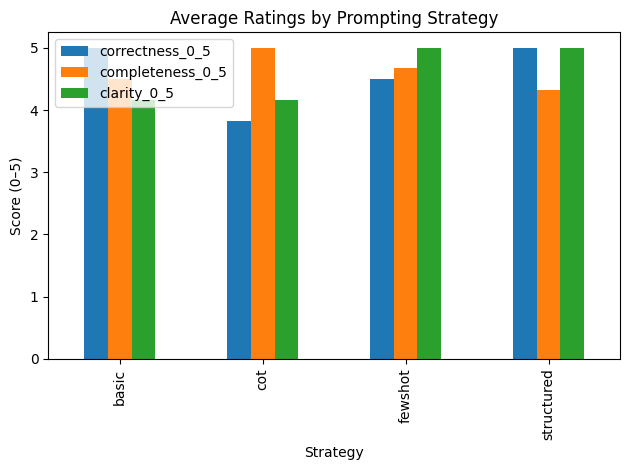

In [16]:

import matplotlib.pyplot as plt

summary.plot(kind="bar")
plt.title("Average Ratings by Prompting Strategy")
plt.ylabel("Score (0–5)")
plt.xlabel("Strategy")
plt.tight_layout()
plt.show()
